# CIS I — Assignment 1: Pivot Calibration

This notebook walks through the pivot-calibration scenario from the
assignment (Figure 1): a pointer and a calibration object, each
carrying a marker body, observed by an optical tracker. Your job is to
**design** the marker-sphere layouts and workspace placements, then
**calibrate** the pointer's tip position `p_tip` to within about 2mm.

Everything runs against `src.simulation`, a self-contained simulator that plays the role of the physical tracker +
hand-guided robot + calibration sensor described in the handout. It injects measurement noise — your code never sees ground truth
except where explicitly noted for **validation/reporting** in Step 8 (real
hardware wouldn't give you that; the point there is to report your achieved
accuracy, not to use the ground truth in your calibration math itself).



In [641]:
import sys, os

# Add the assignment root so the local src package can be imported when this
# notebook is launched from the notebooks directory.
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import matplotlib.pyplot as plt
import unittest
from types import SimpleNamespace
from src import simulation
from src import vct3, Rot, Frame

# Fix the Monte-Carlo sequence so calibration and validation are reproducible.
np.random.seed(7)
# Print small matrices compactly while retaining millimetre-level precision.
np.set_printoptions(precision=3, suppress=True)


## Step 1: Design the pointer, calibration, and nearby marker bodies

Choose approximate local marker-sphere positions for the pointer, calibration
object, and nearby reference body, together with the pointer tip's approximate
local position `p_tip_approx`. These are your
*nominal design values* — the simulator will independently perturb the
*actual* manufactured positions by a small, noise amount (bounded at
2mm).


In [642]:
# All three rigid bodies use the same five-point triangular-bipyramid topology.
# Keeping their radii and coordinates together makes the design directly comparable.
MARKERS_PER_BODY = 5
PTR_RADIUS_MM = 30.0
CAL_RADIUS_MM = 30.0
NEAR_RADIUS_MM = 175.0

def triangular_bipyramid_positions(radius_mm):
    """Return five centered, noncoplanar marker coordinates at scale R."""
    return [
        vct3(radius_mm, 0.0, 0.0),
        vct3(-radius_mm / 2.0, np.sqrt(3.0) * radius_mm / 2.0, 0.0),
        vct3(-radius_mm / 2.0, -np.sqrt(3.0) * radius_mm / 2.0, 0.0),
        vct3(0.0, 0.0, radius_mm),
        vct3(0.0, 0.0, -radius_mm),
    ]

ptr_local_positions = triangular_bipyramid_positions(PTR_RADIUS_MM)
cal_local_positions = triangular_bipyramid_positions(CAL_RADIUS_MM)
near_local_positions = triangular_bipyramid_positions(NEAR_RADIUS_MM)
for positions in (ptr_local_positions, cal_local_positions, near_local_positions):
    assert len(positions) == MARKERS_PER_BODY
# Nominal pointer tip in the pointer marker-body frame.
ptr_tip_approx = vct3(0.0, 0.0, -150.0)


## Step 2: Approximate workspace poses

Specify approximate poses (as `Frame` class from src) for the tracking camera
(`F_tracker`), calibration object (`F_cal`), and nearby reference (`F_near`), relative to the
workspace. The tracker's usable volume is the tetrahedral region in the
handout's Figure 2 (roughly 100-200cm in front of the tracker, widening
from ~120cm to ~200cm across) — place all tracked bodies inside that volume.


In [643]:
# Frames map local coordinates into the common workspace frame. The tracker
# and calibration-object axes are aligned with the workspace axes.
F_tracker_approx = Frame(Rot.eye(), vct3(300.0, -1500.0, 300.0))
F_cal_approx = Frame(Rot.eye(), vct3(730.0, 402.0, 300.0))
# Place the nearby reference beside the test region, aligned with the central tip height,
# and rotated pi about z.
F_near_approx = Frame(Rot.xyz(0.0, 0.0, np.pi), vct3(-48.0, 300.0, 150.0))


## Step 3: Build the simulation

Fully provided — this just wires up your Step 1/2 design choices through
`simulation`'s `DefineMarkerBody` / `PlaceMarkerBody` / `CreateTracker`
equivalents. `ptr_placed`/`cal_placed`/`near_placed` are `PlacedBody` handles. Each links a
`MarkerBody` and its visible nominal workspace pose to a hidden actual placement,
and is passed to `simulation.sample_marker_bodies(...)` whenever a reading is needed.


In [644]:
# Define the nominal local marker layouts. Hidden manufactured marker
# positions are sampled once on first tracker access and then remain fixed.
ptr_mb = simulation.define_marker_body("ptr_mb", ptr_local_positions)
cal_mb = simulation.define_marker_body("cal_mb", cal_local_positions)
near_mb = simulation.define_marker_body("near_mb", near_local_positions)

# Place the two static reference bodies in their designed workspace poses.
cal_placed = simulation.place_marker_body(cal_mb, F_cal_approx)
near_placed = simulation.place_marker_body(near_mb, F_near_approx)
# Give the pointer a temporary initial placement for Step 3.1 refinement.
# Later calibration and test steps update or replace its actual placement.
# "precise" applies the simulator's smaller commanded-pose placement perturbation;
# it does not change marker manufacturing or tracker measurement noise.
ptr_placed = simulation.place_marker_body(ptr_mb, Frame.eye(), precision="precise")

# Bind the nominal tip to the pointer marker body, then create the tracker.
ptr = simulation.define_pointer("ptr1", ptr_tip_approx, ptr_mb)
trk = simulation.create_tracker("trk1", F_tracker_approx)

print("simulation built:", ptr_mb.name, cal_mb.name, near_mb.name, ptr.name, trk.name)


simulation built: ptr_mb cal_mb near_mb ptr1 trk1


## Step 3.1: Refine `a_ptr,k` / `a_cal,k` / `a_near,k`

> "Observations of marker positions can be used to determine accurate
> estimates of relative positions a_ptr,k of markers on pointer and
> calibration objects... **Hint**: You probably want to take multiple
> readings in order to reduce the uncertainty associated with the a_k
> values."

The same refinement method is applied to the nearby reference marker body.


In [645]:
# -------------------------------------------------------------------------
# Step 3.1 helpers: validate a marker layout and estimate refined local
# marker coordinates from repeated tracker observations.
# -------------------------------------------------------------------------
def _point_matrix(points):
    """Return marker coordinates as an (N, 3) floating-point array."""
    return np.vstack([point.vec.ravel() for point in points])


def _validate_marker_geometry(points):
    """Require at least four finite, noncoplanar marker coordinates."""
    # Check the count before stacking so empty or undersized inputs produce
    # this function's stable validation error rather than a NumPy error.
    if points is None or len(points) < 4:
        raise ValueError("Marker geometry requires at least four points.")
    coordinates = _point_matrix(points)
    if not np.all(np.isfinite(coordinates)):
        raise ValueError("Marker coordinates must be finite.")
    # Centering removes translation. Rank three then confirms that the
    # marker offsets span x, y, and z rather than a line or plane.
    if np.linalg.matrix_rank(coordinates - coordinates.mean(axis=0)) < 3:
        raise ValueError("Marker geometry must be noncoplanar.")


def _inverse_average_marker_batch(batch):
    """Average paired tracker measurements after inverse pose transformation."""
    if not batch:
        raise ValueError("At least one observation is required.")
    marker_count = len(batch[0].markers)
    if marker_count < 4:
        raise ValueError("Each observation must contain at least four markers.")
    # Marker order is assumed to preserve correspondence across snapshots;
    # verify that every snapshot at least contains the same marker count.
    if any(len(observation.markers) != marker_count for observation in batch):
        raise ValueError("Every observation must contain the same number of markers.")
    # Each observed marker is expressed in tracker coordinates. Applying the
    # inverse estimated body frame maps it back into that body's local frame.
    # Resulting shape: (number of snapshots, number of markers, xyz).
    local_samples = np.array([
        [(observation.frame.inv() * marker.p).vec.ravel() for marker in observation.markers]
        for observation in batch
    ])
    # Average each marker's back-transformed samples to estimate its fixed local
    # coordinate while reducing snapshot-to-snapshot measurement variation.
    means = local_samples.mean(axis=0)
    return [vct3(row) for row in means]


def refine_marker_body(trk, placed, n_readings=30, passes=3):
    """Refine local marker coordinates by alternating SVD registration and averaging.

    Args:
        trk: Tracker used to collect repeated marker measurements.
        placed: PlacedBody whose marker model is updated in place.
        n_readings: Number of independent snapshots in each refinement pass.
        passes: Number of alternating registration-and-average passes.

    Returns:
        None. The body's nominal_marker_positions are updated in place.
    """
    if not isinstance(n_readings, int) or not isinstance(passes, int) or n_readings < 1 or passes < 1:
        raise ValueError("n_readings and passes must be positive integers.")
    _validate_marker_geometry(placed.body.nominal_marker_positions)
    # Registration depends on the current nominal geometry. Repeating the
    # register-average-update cycle lets the model converge iteratively.
    for _ in range(passes):
        batch = [
            simulation.sample_marker_bodies(trk, [placed])[placed.body.name]
            for _ in range(n_readings)
        ]
        placed.body.set_marker_positions(_inverse_average_marker_batch(batch))


# Preserve the pre-refinement coordinates so the refinement update can be
# reported marker by marker after the unit-tested function is applied.
placed_bodies_for_refinement = {
    "Pointer": ptr_placed,
    "Calibration": cal_placed,
    "Nearby": near_placed,
}
initial_marker_models = {
    name: _point_matrix(placed.body.nominal_marker_positions)
    for name, placed in placed_bodies_for_refinement.items()
}
for placed in placed_bodies_for_refinement.values():
    refine_marker_body(trk, placed)
# Euclidean model-update magnitude for each marker relative to its initial
# nominal coordinate; this is not error relative to the hidden ground truth.
refinement_changes = {
    name: np.linalg.norm(
        _point_matrix(placed.body.nominal_marker_positions) - initial_marker_models[name], axis=1
    )
    for name, placed in placed_bodies_for_refinement.items()
}

marker_indices = np.arange(1, MARKERS_PER_BODY + 1)
print("\nStep 3.1 refinement change from the nominal model (mm)")
print("Body          " + "  ".join(f"M{k}" for k in marker_indices) + "  Mean")
for body_name, changes in refinement_changes.items():
    print(f"{body_name:<13} " + "  ".join(f"{value:5.3f}" for value in changes) + f"  {changes.mean():5.3f}")



Step 3.1 refinement change from the nominal model (mm)
Body          M1  M2  M3  M4  M5  Mean
Pointer       0.936  1.799  0.710  0.920  1.454  1.164
Calibration   0.348  0.922  0.706  1.580  0.251  0.761
Nearby        0.710  1.372  0.636  1.273  1.085  1.015


## Steps 4-6: Collect pivot-calibration observations

For each observation `j`: hand-guide the pointer near the calibration
object at some desired orientation `R_desired,j`, take one simultaneous
tracker reading of *both* bodies, and read the calibration sensor. Loop
skeleton is provided; you choose how many observations to take, how to
vary `R_desired,j`, and what to do when the calibration sensor reports the
tip as out of range (`sense_tip` returns `None`).


In [646]:
# Collect 60 valid paired observations. The larger attempt limit prevents an
# infinite loop if some hand-guided tips fall outside the 5 mm sensor range.
N_OBSERVATIONS = 60
MAX_GUIDE_ATTEMPTS = 10 * N_OBSERVATIONS

F_ptr_list = []
F_cal_list = []
sensed_tip_list = []
guide_attempts = 0
while len(F_ptr_list) < N_OBSERVATIONS and guide_attempts < MAX_GUIDE_ATTEMPTS:
    # Assign one deterministic orientation to each valid observation index.
    # Invalid sensor readings retry the same nominal orientation.
    observation_index = len(F_ptr_list)
    phase = 2.0 * np.pi * observation_index / N_OBSERVATIONS
    R_desired = Rot.xyz(
        (np.pi / 3.0) * np.sin(phase),
        (np.pi / 3.0) * np.cos(phase),
        phase,
    )
    # Hand-guide the pointer tip near the calibration sensor, then acquire the
    # pointer and calibration bodies in one shared tracker snapshot.
    hg = simulation.hand_guide_pointer(ptr, ptr_placed, cal_placed, R_desired)
    obs = simulation.sample_marker_bodies(trk, [ptr_placed, cal_placed])
    # The sensor reports the tip in the calibration-object frame, or None if
    # the sensed position lies outside its 5 mm valid range.
    sensed = simulation.sense_tip(ptr, hg)
    guide_attempts += 1

    # Discard an invalid sensor reading together with its paired frame estimates.
    if sensed is None:
        continue
    # Store the three paired values at the same index in their parallel lists:
    # pointer-to-tracker frame, calibration-to-tracker frame, and sensed tip.
    F_ptr_list.append(obs["ptr_mb"].frame)
    F_cal_list.append(obs["cal_mb"].frame)
    sensed_tip_list.append(sensed)

# Stop with an explicit error instead of silently calibrating from too few
# valid sensor readings.
if len(F_ptr_list) < N_OBSERVATIONS:
    raise RuntimeError(
        f"Collected {len(F_ptr_list)} valid calibration observations after "
        f"{guide_attempts} attempts; required {N_OBSERVATIONS}."
    )
print(f"collected {len(F_ptr_list)} valid observations in {guide_attempts} hand-guide attempts")


collected 60 valid observations in 61 hand-guide attempts


`sensed_tip_list` contains only valid calibration-sensor readings
`p_sensed,j`, each expressing the pointer tip in the calibration-object
frame with negligible simulated sensor error. `sense_tip(...)` may return
`None` when the sensed position lies outside the 5 mm range; the collection
loop discards that reading together with its paired pointer and calibration
frame estimates. The remaining three lists therefore contain aligned valid
observation triples for Step 7.


## Step 7: Compute a calibrated value for `p_tip`

This is the assignment's core deliverable — implement it yourself and specify the details of implementation in the report.

Each observation `j` gives you three measurements of the same physical
moment: `F_ptr,j` and `F_cal,j` from the tracker, and `p_sensed,j` from the
calibration sensor. Derive how they relate to the unknown `p_tip`, and use
all three in your calibration.

**Corner case to consider**: What are the corner cases you want to analyse here? (e.g. what happens to observations whose `p_sensed,j` is `None`?)

**Minimum data**: how many observations, and what about their rotations,
are needed for the stacked system to actually be solvable? How do you define whether a system is solvable here? Include that in your report


In [647]:
# -------------------------------------------------------------------------
# Step 7 solver: estimate the fixed pointer-frame tip p_tip from paired
# pointer poses, calibration-object poses, and calibration-sensor readings.
# -------------------------------------------------------------------------
def _frame_is_valid(frame, atol=1e-8):
    """Return True for a finite Frame with a proper rotation matrix."""
    if not isinstance(frame, Frame):
        return False
    rotation = frame.R.matrix
    translation = frame.p.vec
    return (
        rotation.shape == (3, 3)
        and translation.shape == (3, 1)
        and np.all(np.isfinite(rotation))
        and np.all(np.isfinite(translation))
        and np.allclose(rotation.T @ rotation, np.eye(3), atol=atol, rtol=0.0)
        and np.isclose(np.linalg.det(rotation), 1.0, atol=atol, rtol=0.0)
    )


def compute_pivot_calibration(F_ptr_list, F_cal_list, sensed_tip_list):
    """Estimate the pointer-frame tip and covariance from paired sensor observations.

    Args:
        F_ptr_list: Pointer-to-tracker Frame estimates.
        F_cal_list: Calibration-object-to-tracker Frame estimates.
        sensed_tip_list: Tip coordinates in the calibration-object frame. None,
            nonfinite, and out-of-range entries are ignored with their paired frames.

    Returns:
        A tuple containing the calibrated vct3 tip and its 3x3 covariance in mm^2.
    """
    if not (len(F_ptr_list) == len(F_cal_list) == len(sensed_tip_list)):
        raise ValueError("Pointer frames, calibration frames, and sensor readings must have equal lengths.")

    # For each valid observation, the coordinate equation is
    #     sensed_tip = R_ptr_in_cal @ p_tip + t_ptr_in_cal.
    # Rearranging gives one 3-row linear block for the unknown p_tip.
    system_blocks = []
    right_hand_sides = []
    single_observation_estimates = []
    for F_ptr, F_cal, sensed in zip(F_ptr_list, F_cal_list, sensed_tip_list):
        # A missing sensor reading carries no tip-position information.
        if sensed is None:
            continue
        # Reject malformed rigid transforms before Frame.inv() assumes that
        # the rotation inverse is its transpose.
        if not _frame_is_valid(F_ptr) or not _frame_is_valid(F_cal):
            raise ValueError(
                "Frame estimates must contain finite proper rotations and finite translations."
            )
        if not isinstance(sensed, vct3):
            raise ValueError("Sensor readings must be vct3 instances or None.")
        sensed_array = sensed.vec.ravel()
        # Ignore nonfinite or physically out-of-range calibration readings.
        if not np.all(np.isfinite(sensed_array)) or sensed.norm() > 5.0 + 1e-9:
            continue

        # Compose the two tracker-frame poses to express the pointer body in
        # the calibration-object frame used by the sensor measurement.
        F_ptr_in_cal = F_cal.inv() * F_ptr
        system_blocks.append(F_ptr_in_cal.R.matrix)
        right_hand_sides.append(sensed_array - F_ptr_in_cal.p.vec.ravel())
        # Also retain the tip estimate from this observation alone. Their
        # scatter is later used to estimate uncertainty of the sample mean.
        single_observation_estimates.append((F_ptr_in_cal.inv() * sensed).vec.ravel())

    valid_count = len(system_blocks)
    # One proper rotation is enough to solve for the three tip coordinates.
    # At least two observations are required only for empirical covariance.
    if valid_count < 2:
        raise ValueError("At least two valid observations are required for an empirical covariance.")

    # Stack N rotation blocks into A with shape (3N, 3), and N translated
    # sensor vectors into B with shape (3N,). Solve A @ p_tip ~= B.
    A = np.vstack(system_blocks)
    B = np.concatenate(right_hand_sides)
    p_tip_vector, _, rank, singular_values = np.linalg.lstsq(A, B, rcond=None)
    # Proper rotation blocks satisfy A.T @ A = N * I and therefore have rank
    # three automatically; retain this check as a final numerical safeguard.
    if rank != 3 or singular_values[-1] <= np.finfo(float).eps * singular_values[0]:
        raise ValueError("The calibration system is rank deficient.")

    # Sample covariance of individual estimates is centered.T @ centered /(N-1).
    # Dividing once more by N produces covariance of their estimated mean.
    # This scatter does not include fixed marker-model bias shared by all readings.
    estimates = np.vstack(single_observation_estimates)
    estimate_mean = estimates.mean(axis=0)
    centered = estimates - estimate_mean
    covariance_of_mean = centered.T @ centered / (valid_count * (valid_count - 1))
    return vct3(p_tip_vector), covariance_of_mean


# Apply the solver to the valid paired observations collected in Steps 4-6.
# The resulting tip estimate is used by every Step 8 prediction.
p_tip_est, p_tip_cov = compute_pivot_calibration(F_ptr_list, F_cal_list, sensed_tip_list)


In [648]:
# Convert the covariance diagonal from variance (mm^2) to per-axis standard
# deviation (mm). clip removes tiny negative round-off values before sqrt.
tip_standard_deviation = np.sqrt(np.clip(np.diag(p_tip_cov), 0.0, None))
print("calibrated p_tip:", p_tip_est)
print("estimated covariance (mm^2):\n", p_tip_cov)
print("estimated std-dev per axis (mm):", tip_standard_deviation)


calibrated p_tip: vct3(x=2.28, y=-4.23, z=-149.51)
Internal Vector:
[[   2.276]
 [  -4.234]
 [-149.507]]
estimated covariance (mm^2):
 [[ 0.003 -0.001  0.001]
 [-0.001  0.004  0.002]
 [ 0.001  0.002  0.003]]
estimated std-dev per axis (mm): [0.058 0.063 0.056]


## Step 8: Validate against test poses

> "**Hint**: You may want to consider placing additional marker bodies
> close to (but not inside) the cube defined by the test volume. However,
> this will also depend on your design for and placement of the
> calibration object."

The nominal test-pose grid is `theta_x, theta_y, theta_z` each in
`{0, +-pi/6, +-pi/3, +-pi/2}` and `p_x, p_y, p_z` each in
`{300, 300+-100, 300+-200}` mm. For each test pose, the assignment requires a
**single observation only** (no averaging).

Think about why the hint suggests an *additional*, nearby reference body?

In [649]:
def marker_geometry_metrics(points):
    """Return radius, spacing, and rotational information metrics for a marker body."""
    coordinates = _point_matrix(points)
    # Centering makes all metrics independent of an arbitrary local origin.
    centered = coordinates - coordinates.mean(axis=0)
    # Rotational information matrix: larger eigenvalues imply that marker
    # displacement changes more strongly under small rotations.
    information = sum(
        np.dot(point, point) * np.eye(3) - np.outer(point, point) for point in centered
    )
    eigenvalues = np.linalg.eigvalsh(information)
    pairwise_distances = [
        np.linalg.norm(coordinates[i] - coordinates[j])
        for i in range(len(coordinates)) for j in range(i + 1, len(coordinates))
    ]
    # Kappa=lambda_max/lambda_min measures directional balance; 1.0 is
    # isotropic, while larger values indicate a weaker rotation direction.
    return (
        np.linalg.norm(centered, axis=1).max(), min(pairwise_distances),
        eigenvalues[0], eigenvalues[-1] / eigenvalues[0],
    )


# Compare the design-time marker coordinates from Step 1, before refinement,
# using scale, separation, rotational information, and conditioning metrics.
designed_marker_layouts = {
    f"Pointer (R={PTR_RADIUS_MM:g} mm)": _point_matrix(ptr_local_positions),
    f"Calibration (R={CAL_RADIUS_MM:g} mm)": _point_matrix(cal_local_positions),
    f"Nearby (R={NEAR_RADIUS_MM:g} mm)": _point_matrix(near_local_positions),
}
print("Five-marker geometry metrics")
print("Body                         N   Radius(mm)   Min spacing(mm)   Lambda min(mm^2)   Kappa")
for body_name, coordinates in designed_marker_layouts.items():
    radius, spacing, lambda_min, condition_number = marker_geometry_metrics(
        [vct3(row) for row in coordinates]
    )
    print(
        f"{body_name:<28} {len(coordinates):2d}   {radius:10.1f}   "
        f"{spacing:15.1f}   {lambda_min:16.1f}   {condition_number:5.2f}"
    )


Five-marker geometry metrics
Body                         N   Radius(mm)   Min spacing(mm)   Lambda min(mm^2)   Kappa
Pointer (R=30 mm)             5         30.0              42.4             2700.0    1.17
Calibration (R=30 mm)         5         30.0              42.4             2700.0    1.17
Nearby (R=175 mm)             5        175.0             247.5            91875.0    1.17


The nearby body was defined and placed alongside the pointer and calibration
bodies, then refined with the same method in Step 3.1. Step 8 reuses that
refined marker model without additional observations.


Now the single-observation test loop. For each nominal test pose `F_t`:
place the pointer there (small, robot-precision placement error, same as
the real system), take one simultaneous reading of the pointer and your
Step-8 reference body, and predict the tip's position (relative to that
reference body) using your calibrated `p_tip`.

**Ground truth for reporting only**: `PlacedBody.actual_placement` and
`MarkerBody.actual_marker_positions` hold the hidden values the simulator
sampled — you have access to them here only because this notebook doesn't
gate them behind a separate eval mode (per the handout: "During debugging
you will have access to all of the ... values. These will not be available
during evaluation."). Use them *only* to compute and report your achieved
error in this section — using them anywhere in your actual calibration math
(Steps 3b/7) kills the point of the assignment.


In [650]:
# Candidate angle/offset values document the assignment's test envelope. The
# representative sets below avoid the full Cartesian-product explosion while
# retaining the centre, faces, corners, intermediate offsets, and large tilts.
thetas = [0, np.pi / 6, -np.pi / 6, np.pi / 3, -np.pi / 3, np.pi / 2, -np.pi / 2]
offsets = [0, 100, -100, 200, -200]
position_offsets = [
    (0, 0, 0),
    (200, 0, 0), (-200, 0, 0), (0, 200, 0), (0, -200, 0), (0, 0, 200), (0, 0, -200),
    (200, 200, 200), (200, 200, -200), (200, -200, 200), (200, -200, -200),
    (-200, 200, 200), (-200, 200, -200), (-200, -200, 200), (-200, -200, -200),
    (100, -100, 100), (-100, 100, -100),
]
orientation_angles = [
    (0, 0, 0),
    (np.pi / 6, 0, 0), (-np.pi / 6, 0, 0),
    (0, np.pi / 6, 0), (0, -np.pi / 6, 0),
    (np.pi / 3, 0, 0), (0, -np.pi / 3, 0),
    (np.pi / 2, 0, 0), (0, -np.pi / 2, 0),
    (np.pi / 6, -np.pi / 6, np.pi / 6),
]
# Form the selected representative set: 17 positions x 10 orientations gives
# 170 pointer poses.
test_poses = [
    Frame(Rot.xyz(rx, ry, rz), vct3(300 + tx, 300 + ty, 300 + tz))
    for tx, ty, tz in position_offsets
    for rx, ry, rz in orientation_angles
]

# The pointer shaft and workspace vertical both point along local/workspace -z.
# Their dot product after placement gives the actual tilt classification.
pointer_axis = vct3(0.0, 0.0, -1.0)
workspace_vertical = vct3(0.0, 0.0, -1.0)
# Hidden ground truth is retrieved only for validation, never for prediction.
actual_tip_local = ptr.get_actual_tip_position().p
test_results = []
for pose_index, F_t_nominal in enumerate(test_poses):
    # Place the pointer with the simulator's small robot-positioning error.
    test_placed = simulation.place_marker_body(ptr_mb, F_t_nominal, precision="precise")
    # Exactly one simultaneous snapshot observes Pointer and Nearby. Their common
    # tracker-pose perturbation cancels in the ideal relative transform, while
    # marker measurement and frame-estimation errors remain.
    observation = simulation.sample_marker_bodies(trk, [test_placed, near_placed])

    # Prediction branch: calibrated pointer tip -> tracker frame -> estimated
    # nearby-reference frame. It uses only observable/calibrated quantities.
    predicted_tip_near = observation["near_mb"].frame.inv() * (observation["ptr_mb"].frame * p_tip_est)
    # Validation branch: use hidden actual placements and the hidden actual tip
    # only to compute the answer against which the prediction is scored.
    actual_tip_near = near_placed.actual_placement.inv() * (test_placed.actual_placement * actual_tip_local)
    error_vector = predicted_tip_near - actual_tip_near

    # Use actual rather than nominal placement to classify the final shaft tilt.
    actual_axis = test_placed.actual_placement.R * pointer_axis
    cosine_tilt = np.clip(actual_axis.dot(workspace_vertical), -1.0, 1.0)
    tilt_degrees = np.degrees(np.arccos(cosine_tilt))
    test_results.append({
        "index": pose_index,
        "nominal_pose": F_t_nominal,
        "predicted_tip_near": predicted_tip_near,
        "actual_tip_near": actual_tip_near,
        "error_vector": error_vector,
        "error_mm": error_vector.norm(),
        "tilt_deg": tilt_degrees,
        "is_core": tilt_degrees <= 45.0,
    })

print(f"evaluated {len(test_results)} representative poses with one tracker observation per pose")


evaluated 170 representative poses with one tracker observation per pose


## Achieved performance

Summarize the tip-position error across the test-pose grid against the
handout's 2mm spec.


In [651]:
# Convert the recorded dictionaries into vectorized arrays for statistics.
errors = np.array([result["error_mm"] for result in test_results])
error_vectors = np.vstack([
    result["error_vector"].vec.ravel() for result in test_results
])
core_mask = np.array([result["is_core"] for result in test_results], dtype=bool)
core_errors = errors[core_mask]
extended_errors = errors[~core_mask]
core_error_vectors = error_vectors[core_mask]

# Report all poses, the required <=45-degree core region, and the deliberately
# more difficult extended region. Pass means Euclidean error <= 2 mm.
summary_rows = [
    (
        "All poses", len(errors), errors.mean(),
        np.sqrt(np.mean(errors ** 2)), errors.max(), np.mean(errors <= 2.0),
    ),
    (
        "Core <=45 deg", len(core_errors), core_errors.mean(),
        np.sqrt(np.mean(core_errors ** 2)), core_errors.max(),
        np.mean(core_errors <= 2.0),
    ),
    (
        "Extended >45 deg", len(extended_errors), extended_errors.mean(),
        np.sqrt(np.mean(extended_errors ** 2)), extended_errors.max(),
        np.mean(extended_errors <= 2.0),
    ),
]
print("Step 8 performance summary")
print("Region               N    Mean(mm)   RMSE(mm)    Max(mm)   Within 2 mm")
for name, count, mean_error, rmse, max_error, pass_fraction in summary_rows:
    print(
        f"{name:<20} {count:3d}   {mean_error:8.3f}   {rmse:8.3f}   "
        f"{max_error:8.3f}     {100.0 * pass_fraction:6.1f}%"
    )

# These statistics describe empirical error scatter across different test poses;
# they are not a repeated-measurement covariance for any single pose.
mean_error_vector = error_vectors.mean(axis=0)
error_covariance = np.cov(error_vectors, rowvar=False, ddof=1)
core_mean_error_vector = core_error_vectors.mean(axis=0)
core_error_covariance = np.cov(core_error_vectors, rowvar=False, ddof=1)
print("\nEmpirical error-vector statistics across test poses")
print(f"All-pose mean error [mm]: {mean_error_vector}")
print("All-pose covariance [mm^2]:")
print(error_covariance)
print(f"Core mean error [mm]: {core_mean_error_vector}")
print("Core covariance [mm^2]:")
print(core_error_covariance)

# List worst cases explicitly so a high average pass rate cannot hide isolated
# poses that violate the 2 mm specification.
print("\nTen largest single-observation errors")
print("Pose   Tilt(deg)   Error(mm)   Region     Meets spec")
for result in sorted(test_results, key=lambda item: item["error_mm"], reverse=True)[:10]:
    region = "core" if result["is_core"] else "extended"
    meets_spec = "yes" if result["error_mm"] <= 2.0 else "no"
    print(
        f"{result['index']:4d}   {result['tilt_deg']:9.2f}   "
        f"{result['error_mm']:9.3f}   {region:<8}   {meets_spec}"
    )


Step 8 performance summary
Region               N    Mean(mm)   RMSE(mm)    Max(mm)   Within 2 mm
All poses            170      1.114      1.230      2.490       95.3%
Core <=45 deg        102      1.110      1.231      2.490       95.1%
Extended >45 deg      68      1.121      1.228      2.397       95.6%

Empirical error-vector statistics across test poses
All-pose mean error [mm]: [-0.051 -0.266 -0.537]
All-pose covariance [mm^2]:
[[ 0.235 -0.101  0.246]
 [-0.101  0.514  0.12 ]
 [ 0.246  0.12   0.41 ]]
Core mean error [mm]: [-0.102 -0.369 -0.536]
Core covariance [mm^2]:
[[ 0.24  -0.111  0.247]
 [-0.111  0.468  0.098]
 [ 0.247  0.098  0.384]]

Ten largest single-observation errors
Pose   Tilt(deg)   Error(mm)   Region     Meets spec
 102       29.13       2.490   core       no
 108       89.73       2.397   extended   no
 106       60.57       2.390   extended   no
 104       29.84       2.387   core       no
 100        1.10       2.264   core       no
  98       89.69       2.199  

## Unit tests and sensitivity studies

The deterministic unit tests below verify exact mathematical behavior and
input validation. The sensitivity studies use repeated noisy trials to show
how marker geometry, observation count, and refinement passes affect accuracy;
their trends are reported rather than treated as strict pass/fail conditions.

Hidden simulated values are used only as known answers inside these tests and
studies. They are not used by the calibration implementation.

In [652]:
# -------------------------------------------------------------------------
# Shared deterministic fixtures and sensitivity-study helpers.
# -------------------------------------------------------------------------
def _run_unit_test(test_case, failure_message):
    """Run one TestCase class and stop the notebook if it fails."""
    result = unittest.TextTestRunner(verbosity=2).run(
        unittest.defaultTestLoader.loadTestsFromTestCase(test_case)
    )
    if not result.wasSuccessful():
        raise AssertionError(failure_message)
    return result


def _unit_five_marker_points(radius=1.0):
    """Return the five-marker triangular-bipyramid geometry."""
    return triangular_bipyramid_positions(radius)


def _unit_marker_observation(points, frame, offsets=None):
    """Create a synthetic tracker observation from known local markers."""
    offsets = np.zeros((len(points), 3)) if offsets is None else np.asarray(offsets)
    markers = [
        SimpleNamespace(p=frame * vct3(point.vec.ravel() + offset))
        for point, offset in zip(points, offsets)
    ]
    return SimpleNamespace(frame=frame, markers=markers)


def _synthetic_calibration_case():
    """Build exact paired frames whose sensor readings are analytically known."""
    true_tip = vct3(1.5, -0.75, -149.0)
    rotations = [
        Rot.eye(),
        Rot.xyz(0.4, -0.2, 0.1),
        Rot.xyz(-0.5, 0.3, -0.4),
        Rot.xyz(0.2, 0.6, -0.3),
    ]
    sensed_targets = [
        vct3(0.2, -0.1, 0.1),
        vct3(-0.2, 0.1, 0.0),
        vct3(0.0, 0.2, -0.1),
        vct3(0.1, 0.0, 0.2),
    ]
    cal_frames = [Frame.eye() for _ in rotations]
    # Choosing t = sensed - R @ true_tip makes every observation exact.
    ptr_frames = [
        Frame(rotation, sensed - rotation * true_tip)
        for rotation, sensed in zip(rotations, sensed_targets)
    ]
    return true_tip, ptr_frames, cal_frames, sensed_targets


def _marker_layout_for_count(marker_count, radius):
    """Return centered, noncoplanar layouts with a common maximum radius."""
    if marker_count == 4:
        units = np.array([
            [1, 1, 1], [1, -1, -1],
            [-1, 1, -1], [-1, -1, 1],
        ], dtype=float) / np.sqrt(3.0)
    elif marker_count == 5:
        return triangular_bipyramid_positions(radius)
    elif marker_count == 6:
        units = np.array([
            [1, 0, 0], [-1, 0, 0],
            [0, 1, 0], [0, -1, 0],
            [0, 0, 1], [0, 0, -1],
        ], dtype=float)
    elif marker_count == 8:
        units = np.array([
            [x, y, z]
            for x in (-1, 1) for y in (-1, 1) for z in (-1, 1)
        ], dtype=float) / np.sqrt(3.0)
    else:
        raise ValueError("Supported sensitivity-study marker counts are 4, 5, 6, and 8.")
    return [vct3(radius * row) for row in units]


def _aligned_marker_rmse(nominal_points, actual_points, registration_tracker):
    """Compare two marker models after removing their arbitrary rigid gauge."""
    alignment = registration_tracker.procrustes_solver(nominal_points, actual_points)
    squared_errors = [
        (alignment * nominal - actual.p).norm() ** 2
        for nominal, actual in zip(nominal_points, actual_points)
    ]
    return float(np.sqrt(np.mean(squared_errors)))


def _refinement_trial(points, n_readings, passes, seed):
    """Run refinement on a fresh body and return aligned marker-model RMSE."""
    random_state = np.random.get_state()
    try:
        np.random.seed(seed)
        body = simulation.define_marker_body(f"unit_refine_{seed}", points)
        placed = simulation.place_marker_body(
            body,
            Frame(Rot.xyz(0.2, -0.1, 0.3), vct3(300.0, 300.0, 300.0)),
            precision="precise",
        )
        tracker = simulation.create_tracker(
            f"unit_tracker_{seed}",
            Frame(Rot.eye(), vct3(300.0, -1500.0, 300.0)),
        )
        # Freeze the hidden manufactured geometry before refinement updates the
        # nominal model, then use it only as the test's known answer.
        actual_points = body.get_actual_marker_positions()
        refine_marker_body(tracker, placed, n_readings=n_readings, passes=passes)
        return _aligned_marker_rmse(
            body.nominal_marker_positions, actual_points, tracker
        )
    finally:
        np.random.set_state(random_state)


def _summarize_trials(parameter_values, trial_function, seeds):
    """Return trial matrix, mean, and sample standard deviation by parameter."""
    trial_values = np.array([
        [trial_function(value, seed) for seed in seeds]
        for value in parameter_values
    ])
    return trial_values, trial_values.mean(axis=1), trial_values.std(axis=1, ddof=1)


def _noisy_calibration_trial(observation_count, seed, sensor_std=0.35):
    """Return tip error for exact frames and noisy calibration-sensor readings."""
    rng = np.random.default_rng(seed)
    true_tip = vct3(1.5, -0.75, -149.0)
    ptr_frames, cal_frames, sensed = [], [], []
    for _ in range(observation_count):
        angles = rng.uniform(-0.8, 0.8, size=3)
        rotation = Rot.xyz(*angles)
        true_sensed = vct3()
        ptr_frames.append(Frame(rotation, true_sensed - rotation * true_tip))
        cal_frames.append(Frame.eye())
        sensed.append(vct3(rng.normal(0.0, sensor_std, size=3)))
    estimated, _ = compute_pivot_calibration(ptr_frames, cal_frames, sensed)
    return (estimated - true_tip).norm()


def _estimate_frame_from_noisy_markers(points, true_frame, rng, tracker, noise_std=0.25):
    """Estimate one frame from corresponding marker points with Gaussian noise."""
    observed = [
        SimpleNamespace(
            p=true_frame * point + vct3(rng.normal(0.0, noise_std, size=3))
        )
        for point in points
    ]
    return tracker.procrustes_solver(points, observed)


def _geometry_to_tip_trial(points, seed, observation_count=15):
    """Propagate marker-registration noise through tip calibration."""
    rng = np.random.default_rng(seed)
    tracker = simulation.create_tracker("unit_registration_tracker", Frame.eye())
    true_tip = vct3(1.5, -0.75, -149.0)
    cal_true = Frame(Rot.xyz(0.15, -0.10, 0.08), vct3(200.0, 100.0, 400.0))
    ptr_frames, cal_frames, sensed = [], [], []
    for _ in range(observation_count):
        rotation = Rot.xyz(*rng.uniform(-0.8, 0.8, size=3))
        sensor_value = vct3()
        ptr_in_cal = Frame(rotation, sensor_value - rotation * true_tip)
        ptr_true = cal_true * ptr_in_cal
        ptr_frames.append(
            _estimate_frame_from_noisy_markers(points, ptr_true, rng, tracker)
        )
        cal_frames.append(
            _estimate_frame_from_noisy_markers(points, cal_true, rng, tracker)
        )
        sensed.append(sensor_value)
    estimated, _ = compute_pivot_calibration(ptr_frames, cal_frames, sensed)
    return (estimated - true_tip).norm()


UNIT_SENSITIVITY_SEEDS = tuple(range(100, 108))

### A. Marker-body refinement

These tests cover marker-layout validity, inverse pose removal, measurement
averaging, and the input contract of `refine_marker_body` and its helpers.
The following sensitivity studies use a fresh marker body for every trial so
that one setting never inherits another setting's refined model.

#### A.1 Marker-layout construction

The standard five-marker layout must have the requested radius, finite
coordinates, and enough noncoplanar points for a three-dimensional rigid-body
frame. Failure means the geometry is invalid before any observation is taken.

In [653]:
class TestMarkerDesign(unittest.TestCase):
    def test_five_markers_follow_design_radius(self):
        points = _unit_five_marker_points()
        self.assertEqual(len(points), MARKERS_PER_BODY)
        self.assertAlmostEqual(
            np.linalg.norm(_point_matrix(points), axis=1).max(), 1.0, places=12
        )
        _validate_marker_geometry(points)


_run_unit_test(TestMarkerDesign, "Marker-design unit test failed.")

test_five_markers_follow_design_radius (__main__.TestMarkerDesign.test_five_markers_follow_design_radius) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.001s

OK


<unittest.runner.TextTestResult run=1 errors=0 failures=0>

#### A.2 Exact recovery after inverse pose transformation

The identity case checks the simplest coordinate conversion. The second case
applies a known rotation and translation and verifies that transforming the
observed points back into the body frame recovers the original local geometry.

In [654]:
class TestInversePoseRecovery(unittest.TestCase):
    def test_identity_frame(self):
        points = _unit_five_marker_points()
        observation = _unit_marker_observation(points, Frame.eye())
        refined = _point_matrix(_inverse_average_marker_batch([observation]))
        np.testing.assert_allclose(refined, _point_matrix(points), atol=1e-12)

    def test_nontrivial_rigid_frame(self):
        points = _unit_five_marker_points()
        frame = Frame(Rot.xyz(0.3, -0.2, 0.4), vct3(20.0, -30.0, 40.0))
        observation = _unit_marker_observation(points, frame)
        refined = _point_matrix(_inverse_average_marker_batch([observation]))
        np.testing.assert_allclose(refined, _point_matrix(points), atol=1e-12)


_run_unit_test(TestInversePoseRecovery, "Inverse-pose-recovery unit test failed.")

test_identity_frame (__main__.TestInversePoseRecovery.test_identity_frame) ... ok
test_nontrivial_rigid_frame (__main__.TestInversePoseRecovery.test_nontrivial_rigid_frame) ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.001s

OK


<unittest.runner.TextTestResult run=2 errors=0 failures=0>

#### A.3 Averaging measurement noise

Two observations receive equal and opposite marker offsets. Their arithmetic
mean has an analytically known answer, so this is a deterministic check of the
averaging implementation rather than a claim that random errors always cancel.

In [655]:
class TestOppositeNoiseCancellation(unittest.TestCase):
    def test_opposite_noise_cancels(self):
        points = _unit_five_marker_points()
        noise = np.full((len(points), 3), 0.2)
        batch = [
            _unit_marker_observation(points, Frame.eye(), noise),
            _unit_marker_observation(points, Frame.eye(), -noise),
        ]
        refined = _point_matrix(_inverse_average_marker_batch(batch))
        np.testing.assert_allclose(refined, _point_matrix(points), atol=1e-12)


_run_unit_test(TestOppositeNoiseCancellation, "Noise-averaging unit test failed.")

test_opposite_noise_cancels (__main__.TestOppositeNoiseCancellation.test_opposite_noise_cancels) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.001s

OK


<unittest.runner.TextTestResult run=1 errors=0 failures=0>

#### A.4 Invalid refinement inputs

Malformed geometry and observation batches indicate programming or test-data
errors, so they raise `ValueError` instead of being silently discarded. Invalid
`n_readings` and `passes` settings are rejected before simulation begins.

In [656]:
class TestRefinementInputValidation(unittest.TestCase):
    def test_empty_batch_is_rejected(self):
        with self.assertRaisesRegex(ValueError, "At least one observation"):
            _inverse_average_marker_batch([])

    def test_fewer_than_four_observed_markers_is_rejected(self):
        points = _unit_five_marker_points()[:3]
        observation = _unit_marker_observation(points, Frame.eye())
        with self.assertRaisesRegex(ValueError, "at least four markers"):
            _inverse_average_marker_batch([observation])

    def test_inconsistent_observation_counts_are_rejected(self):
        points = _unit_five_marker_points()
        batch = [
            _unit_marker_observation(points, Frame.eye()),
            _unit_marker_observation(points[:-1], Frame.eye()),
        ]
        with self.assertRaisesRegex(ValueError, "same number of markers"):
            _inverse_average_marker_batch(batch)

    def test_coplanar_geometry_is_rejected(self):
        coplanar_points = [
            vct3(0, 0, 0), vct3(1, 0, 0),
            vct3(0, 1, 0), vct3(1, 1, 0),
        ]
        with self.assertRaisesRegex(ValueError, "noncoplanar"):
            _validate_marker_geometry(coplanar_points)

    def test_nonfinite_geometry_is_rejected(self):
        points = _unit_five_marker_points()
        points[0] = vct3(np.nan, 0.0, 0.0)
        with self.assertRaisesRegex(ValueError, "finite"):
            _validate_marker_geometry(points)

    def test_invalid_refinement_controls_are_rejected(self):
        invalid_controls = [
            {"n_readings": 0, "passes": 1},
            {"n_readings": 1, "passes": 0},
            {"n_readings": 1.5, "passes": 1},
            {"n_readings": 1, "passes": 1.5},
        ]
        for controls in invalid_controls:
            with self.subTest(controls=controls):
                with self.assertRaisesRegex(ValueError, "positive integers"):
                    refine_marker_body(None, None, **controls)


_run_unit_test(
    TestRefinementInputValidation,
    "Refinement-input-validation unit test failed.",
)
print("\nRefinement error-handling summary")
print("Case                                  Expected       Result")
for case in (
    "Empty observation batch",
    "Fewer than four markers",
    "Inconsistent marker counts",
    "Coplanar geometry",
    "Nonfinite geometry",
    "Invalid readings/passes",
):
    print(f"{case:<38} ValueError     PASS")

test_coplanar_geometry_is_rejected (__main__.TestRefinementInputValidation.test_coplanar_geometry_is_rejected) ... ok
test_empty_batch_is_rejected (__main__.TestRefinementInputValidation.test_empty_batch_is_rejected) ... ok
test_fewer_than_four_observed_markers_is_rejected (__main__.TestRefinementInputValidation.test_fewer_than_four_observed_markers_is_rejected) ... ok
test_inconsistent_observation_counts_are_rejected (__main__.TestRefinementInputValidation.test_inconsistent_observation_counts_are_rejected) ... ok
test_invalid_refinement_controls_are_rejected (__main__.TestRefinementInputValidation.test_invalid_refinement_controls_are_rejected) ... ok
test_nonfinite_geometry_is_rejected (__main__.TestRefinementInputValidation.test_nonfinite_geometry_is_rejected) ... ok

----------------------------------------------------------------------
Ran 6 tests in 0.003s

OK



Refinement error-handling summary
Case                                  Expected       Result
Empty observation batch                ValueError     PASS
Fewer than four markers                ValueError     PASS
Inconsistent marker counts             ValueError     PASS
Coplanar geometry                      ValueError     PASS
Nonfinite geometry                     ValueError     PASS
Invalid readings/passes                ValueError     PASS


#### A.5 Effect of marker count

Four, five, six, and eight-marker designs are compared at the same maximum
radius. Each point is the mean aligned marker-model RMSE over repeated noisy
refinement trials; the error bars show one sample standard deviation. This is
a sensitivity result, so it has no monotonicity assertion.

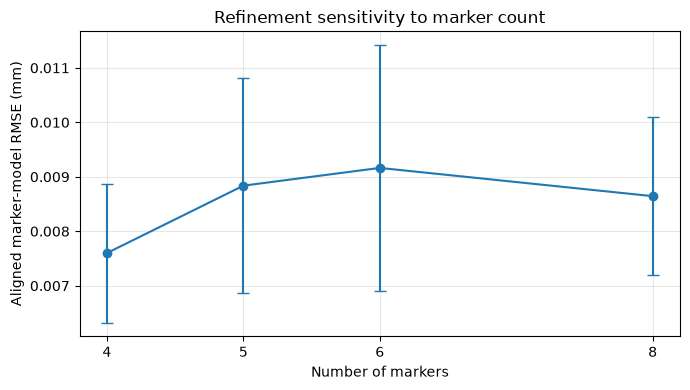

In [657]:
marker_counts = np.array([4, 5, 6, 8])
_, marker_count_means, marker_count_stds = _summarize_trials(
    marker_counts,
    lambda count, seed: _refinement_trial(
        _marker_layout_for_count(int(count), radius=60.0),
        n_readings=10,
        passes=3,
        seed=seed,
    ),
    UNIT_SENSITIVITY_SEEDS,
)

figure, axis = plt.subplots(figsize=(7, 4))
axis.errorbar(marker_counts, marker_count_means, yerr=marker_count_stds, fmt="o-", capsize=4)
axis.set(
    title="Refinement sensitivity to marker count",
    xlabel="Number of markers",
    ylabel="Aligned marker-model RMSE (mm)",
    xticks=marker_counts,
)
axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### A.6 Effect of marker-body radius

This experiment fixes the five-marker topology and changes only its radius.
Every radius is evaluated with the same number of readings, passes, and random
seeds, which prevents marker count or sampling effort from confounding the
comparison.

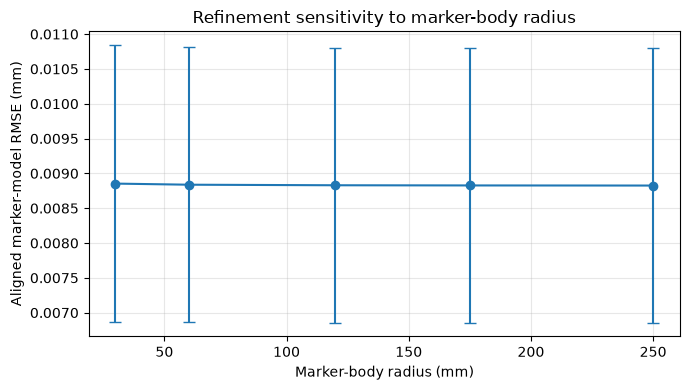

In [658]:
refinement_radii = np.array([30.0, 60.0, 120.0, 175.0, 250.0])
_, radius_means, radius_stds = _summarize_trials(
    refinement_radii,
    lambda radius, seed: _refinement_trial(
        triangular_bipyramid_positions(radius),
        n_readings=10,
        passes=3,
        seed=seed,
    ),
    UNIT_SENSITIVITY_SEEDS,
)

figure, axis = plt.subplots(figsize=(7, 4))
axis.errorbar(refinement_radii, radius_means, yerr=radius_stds, fmt="o-", capsize=4)
axis.set(
    title="Refinement sensitivity to marker-body radius",
    xlabel="Marker-body radius (mm)",
    ylabel="Aligned marker-model RMSE (mm)",
)
axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### A.7 Effect of observations per refinement pass

`refine_marker_body` accepts one or more observations per pass. The plot checks
how repeated averaging changes the recovered marker model while keeping the
five-marker geometry and number of passes fixed.

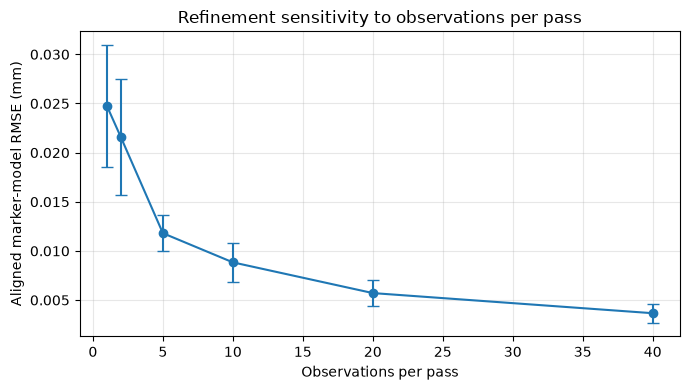

In [659]:
refinement_reading_counts = np.array([1, 2, 5, 10, 20, 40])
_, reading_means, reading_stds = _summarize_trials(
    refinement_reading_counts,
    lambda count, seed: _refinement_trial(
        triangular_bipyramid_positions(60.0),
        n_readings=int(count),
        passes=3,
        seed=seed,
    ),
    UNIT_SENSITIVITY_SEEDS,
)

figure, axis = plt.subplots(figsize=(7, 4))
axis.errorbar(
    refinement_reading_counts, reading_means, yerr=reading_stds,
    fmt="o-", capsize=4,
)
axis.set(
    title="Refinement sensitivity to observations per pass",
    xlabel="Observations per pass",
    ylabel="Aligned marker-model RMSE (mm)",
)
axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### A.8 Effect of refinement passes

Each pass performs a new register-average-update cycle. More passes need not
improve every random trial because the body model can continue responding to
measurement noise, so the result is shown as a distribution rather than a
strict increasing-or-decreasing assertion.

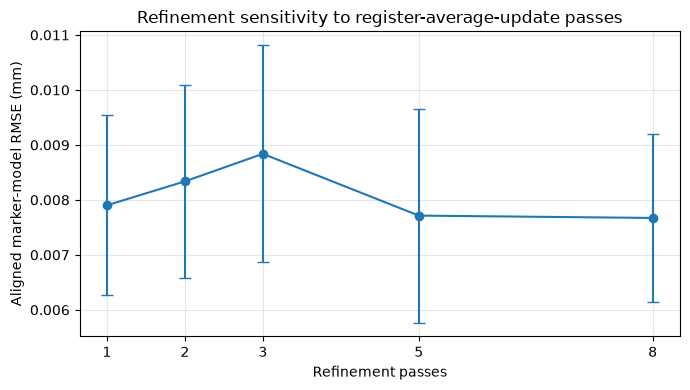

In [660]:
refinement_pass_counts = np.array([1, 2, 3, 5, 8])
_, pass_means, pass_stds = _summarize_trials(
    refinement_pass_counts,
    lambda count, seed: _refinement_trial(
        triangular_bipyramid_positions(60.0),
        n_readings=10,
        passes=int(count),
        seed=seed,
    ),
    UNIT_SENSITIVITY_SEEDS,
)

figure, axis = plt.subplots(figsize=(7, 4))
axis.errorbar(refinement_pass_counts, pass_means, yerr=pass_stds, fmt="o-", capsize=4)
axis.set(
    title="Refinement sensitivity to register-average-update passes",
    xlabel="Refinement passes",
    ylabel="Aligned marker-model RMSE (mm)",
    xticks=refinement_pass_counts,
)
axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### B. Pointer-tip calibration

`compute_pivot_calibration` receives already estimated pointer and calibration
frames rather than raw markers. Its deterministic tests therefore focus on the
least-squares solution, covariance, filtering, and malformed inputs. Separate
integration studies below propagate marker-registration error into the tip.

#### B.1 Exact synthetic tip recovery

Exact frame pairs and sensor readings are constructed from a known pointer tip.
The solver must recover all three coordinates to numerical precision. A table
shows the coordinate errors directly; a true-versus-estimated bar chart would
hide these small differences behind the approximately -149 mm z coordinate.

In [661]:
class TestExactTipRecovery(unittest.TestCase):
    def test_exact_tip_recovery(self):
        true_tip, ptr_frames, cal_frames, sensed = _synthetic_calibration_case()
        estimated, _ = compute_pivot_calibration(ptr_frames, cal_frames, sensed)
        np.testing.assert_allclose(estimated.vec, true_tip.vec, atol=1e-10)


_run_unit_test(TestExactTipRecovery, "Exact-tip-recovery unit test failed.")
unit_true_tip, unit_ptr_frames, unit_cal_frames, unit_sensed = _synthetic_calibration_case()
unit_tip_estimate, _ = compute_pivot_calibration(
    unit_ptr_frames, unit_cal_frames, unit_sensed
)
print("\nExact-recovery reference data (mm)")
print("Axis   True      Estimated    Absolute error")
for axis_name, truth, estimate in zip(
    "xyz", unit_true_tip.vec.ravel(), unit_tip_estimate.vec.ravel()
):
    print(f"{axis_name:>4} {truth:9.4f} {estimate:12.4f} {abs(estimate - truth):15.3e}")

test_exact_tip_recovery (__main__.TestExactTipRecovery.test_exact_tip_recovery) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.001s

OK



Exact-recovery reference data (mm)
Axis   True      Estimated    Absolute error
   x    1.5000       1.5000       1.332e-15
   y   -0.7500      -0.7500       7.661e-15
   z -149.0000    -149.0000       0.000e+00


#### B.2 Empirical covariance calculation

Identical exact per-observation tip estimates must produce zero covariance.
For estimates at -1, 0, and +1 mm along x, the sample variance is 1 mm² and
the covariance of their three-sample mean is therefore 1/3 mm².

In [662]:
class TestCalibrationCovariance(unittest.TestCase):
    def test_noiseless_covariance_is_zero(self):
        _, ptr_frames, cal_frames, sensed = _synthetic_calibration_case()
        _, covariance = compute_pivot_calibration(ptr_frames, cal_frames, sensed)
        np.testing.assert_allclose(covariance, np.zeros((3, 3)), atol=1e-20)

    def test_known_covariance_of_mean(self):
        true_tip = vct3(0.0, 0.0, -150.0)
        ptr_frames = [Frame(Rot.eye(), -true_tip) for _ in range(3)]
        sensed = [vct3(-1.0, 0.0, 0.0), vct3(), vct3(1.0, 0.0, 0.0)]
        estimated, covariance = compute_pivot_calibration(
            ptr_frames, [Frame.eye()] * 3, sensed
        )
        np.testing.assert_allclose(estimated.vec, true_tip.vec, atol=1e-12)
        self.assertAlmostEqual(covariance[0, 0], 1.0 / 3.0, places=12)


_run_unit_test(TestCalibrationCovariance, "Calibration-covariance unit test failed.")

test_known_covariance_of_mean (__main__.TestCalibrationCovariance.test_known_covariance_of_mean) ... ok
test_noiseless_covariance_is_zero (__main__.TestCalibrationCovariance.test_noiseless_covariance_is_zero) ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.004s

OK


<unittest.runner.TextTestResult run=2 errors=0 failures=0>

#### B.3 Filtering unusable sensor readings

Missing, nonfinite, and physically out-of-range sensor values contain no usable
tip information. They and their paired frames are skipped, while the remaining
valid observations must still reproduce the known result. A value of the wrong
Python type is handled separately as a programming error in B.4.

In [663]:
class TestInvalidSensorFiltering(unittest.TestCase):
    def test_unusable_sensor_entries_are_filtered(self):
        true_tip, ptr_frames, cal_frames, sensed = _synthetic_calibration_case()
        estimated, _ = compute_pivot_calibration(
            ptr_frames + [Frame.eye(), Frame.eye(), Frame.eye()],
            cal_frames + [Frame.eye(), Frame.eye(), Frame.eye()],
            sensed + [None, vct3(np.nan, 0.0, 0.0), vct3(10.0, 0.0, 0.0)],
        )
        np.testing.assert_allclose(estimated.vec, true_tip.vec, atol=1e-10)


_run_unit_test(TestInvalidSensorFiltering, "Sensor-filtering unit test failed.")

test_unusable_sensor_entries_are_filtered (__main__.TestInvalidSensorFiltering.test_unusable_sensor_entries_are_filtered) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.003s

OK


<unittest.runner.TextTestResult run=1 errors=0 failures=0>

#### B.4 Invalid calibration inputs and the minimum valid count

Malformed frames and inconsistent input structures raise `ValueError`. A valid
rotation is always invertible, so the singular-matrix case represents an invalid
`Frame`, not a normal least-squares condition. Although one proper rotation is
enough to solve the three tip coordinates, this implementation requires at
least two valid observations to estimate empirical covariance.

In [664]:
class TestCalibrationInputValidation(unittest.TestCase):
    def test_mismatched_list_lengths_are_rejected(self):
        with self.assertRaisesRegex(ValueError, "equal lengths"):
            compute_pivot_calibration([Frame.eye()], [], [vct3()])

    def test_nonorthogonal_rotation_is_rejected(self):
        improper = Frame(Rot(matrix=np.diag([1.0, 1.0, 2.0])), vct3())
        with self.assertRaisesRegex(ValueError, "proper rotations"):
            compute_pivot_calibration(
                [improper, improper], [Frame.eye(), Frame.eye()], [vct3(), vct3()]
            )

    def test_singular_rotation_is_rejected(self):
        singular = Frame(Rot(matrix=np.diag([1.0, 1.0, 0.0])), vct3())
        with self.assertRaisesRegex(ValueError, "proper rotations"):
            compute_pivot_calibration(
                [singular, singular], [Frame.eye(), Frame.eye()], [vct3(), vct3()]
            )

    def test_nonfinite_frame_is_rejected(self):
        nonfinite = Frame(Rot.eye(), vct3(np.nan, 0.0, 0.0))
        with self.assertRaisesRegex(ValueError, "finite proper rotations"):
            compute_pivot_calibration(
                [nonfinite, nonfinite], [Frame.eye(), Frame.eye()], [vct3(), vct3()]
            )

    def test_invalid_sensor_type_is_rejected(self):
        with self.assertRaisesRegex(ValueError, "vct3 instances or None"):
            compute_pivot_calibration(
                [Frame.eye(), Frame.eye()],
                [Frame.eye(), Frame.eye()],
                ["invalid", vct3()],
            )

    def test_fewer_than_two_valid_observations_is_rejected(self):
        with self.assertRaisesRegex(ValueError, "At least two valid observations"):
            compute_pivot_calibration(
                [Frame.eye(), Frame.eye()],
                [Frame.eye(), Frame.eye()],
                [vct3(), None],
            )


_run_unit_test(
    TestCalibrationInputValidation,
    "Calibration-input-validation unit test failed.",
)
print("\nCalibration error-handling summary")
print("Case                                  Expected       Result")
for case in (
    "Mismatched list lengths",
    "Nonorthogonal rotation",
    "Singular rotation",
    "Nonfinite frame",
    "Invalid sensor type",
    "Fewer than two valid observations",
):
    print(f"{case:<38} ValueError     PASS")

test_fewer_than_two_valid_observations_is_rejected (__main__.TestCalibrationInputValidation.test_fewer_than_two_valid_observations_is_rejected) ... ok
test_invalid_sensor_type_is_rejected (__main__.TestCalibrationInputValidation.test_invalid_sensor_type_is_rejected) ... ok
test_mismatched_list_lengths_are_rejected (__main__.TestCalibrationInputValidation.test_mismatched_list_lengths_are_rejected) ... ok
test_nonfinite_frame_is_rejected (__main__.TestCalibrationInputValidation.test_nonfinite_frame_is_rejected) ... ok
test_nonorthogonal_rotation_is_rejected (__main__.TestCalibrationInputValidation.test_nonorthogonal_rotation_is_rejected) ... ok
test_singular_rotation_is_rejected (__main__.TestCalibrationInputValidation.test_singular_rotation_is_rejected) ... ok

----------------------------------------------------------------------
Ran 6 tests in 0.007s

OK



Calibration error-handling summary
Case                                  Expected       Result
Mismatched list lengths                ValueError     PASS
Nonorthogonal rotation                 ValueError     PASS
Singular rotation                      ValueError     PASS
Nonfinite frame                        ValueError     PASS
Invalid sensor type                    ValueError     PASS
Fewer than two valid observations      ValueError     PASS


#### B.5 Effect of calibration observation count

Noisy synthetic sensor readings are generated from known exact frames. The
one-observation boundary is already checked in B.4; this study begins at two
valid observations and shows the mean tip error and one standard deviation over
repeated trials. The dashed reference has the expected inverse-square-root form.

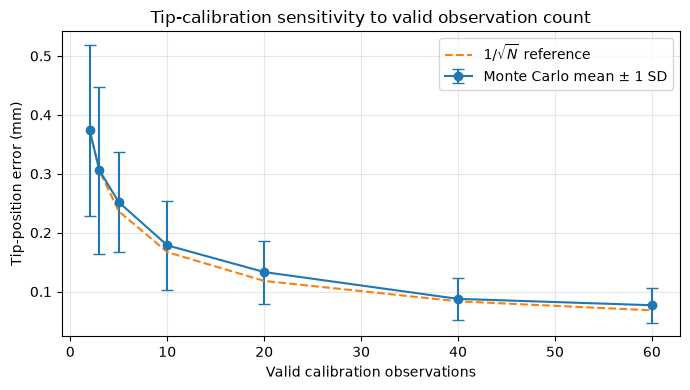

In [665]:
calibration_observation_counts = np.array([2, 3, 5, 10, 20, 40, 60])
calibration_seeds = tuple(range(300, 340))
_, calibration_count_means, calibration_count_stds = _summarize_trials(
    calibration_observation_counts,
    lambda count, seed: _noisy_calibration_trial(int(count), seed),
    calibration_seeds,
)
inverse_sqrt_reference = calibration_count_means[0] * np.sqrt(
    calibration_observation_counts[0] / calibration_observation_counts
)

figure, axis = plt.subplots(figsize=(7, 4))
axis.errorbar(
    calibration_observation_counts,
    calibration_count_means,
    yerr=calibration_count_stds,
    fmt="o-",
    capsize=4,
    label="Monte Carlo mean ± 1 SD",
)
axis.plot(
    calibration_observation_counts,
    inverse_sqrt_reference,
    "--",
    label=r"$1/\sqrt{N}$ reference",
)
axis.set(
    title="Tip-calibration sensitivity to valid observation count",
    xlabel="Valid calibration observations",
    ylabel="Tip-position error (mm)",
)
axis.grid(alpha=0.3)
axis.legend()
plt.tight_layout()
plt.show()

#### B.6 End-to-end marker geometry effect on calibrated tip

`compute_pivot_calibration` does not receive raw marker coordinates, so marker
count and radius cannot affect it directly. This integration study first
estimates noisy pointer and calibration frames from markers and then sends those
frames to the tip solver. The two panels therefore show how upstream marker
registration error propagates into the final calibrated tip.

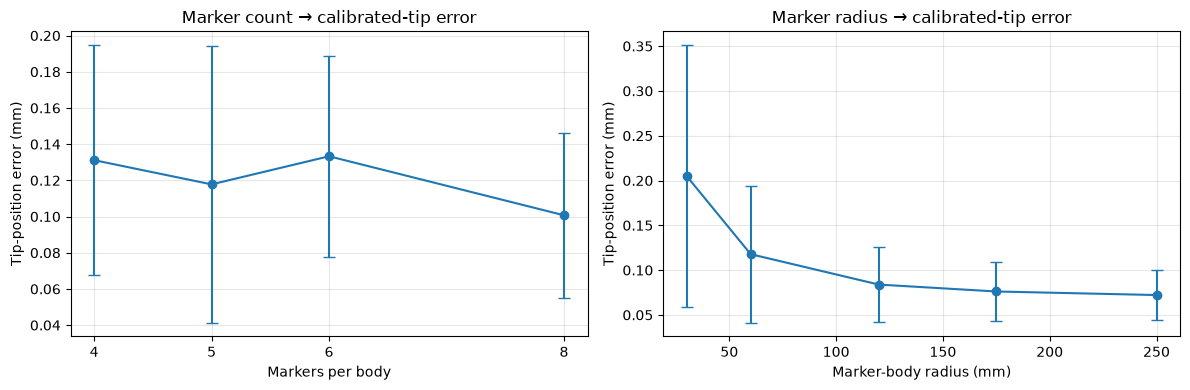

In [666]:
geometry_seeds = tuple(range(500, 520))
integration_marker_counts = np.array([4, 5, 6, 8])
_, geometry_count_means, geometry_count_stds = _summarize_trials(
    integration_marker_counts,
    lambda count, seed: _geometry_to_tip_trial(
        _marker_layout_for_count(int(count), radius=60.0), seed
    ),
    geometry_seeds,
)

integration_radii = np.array([30.0, 60.0, 120.0, 175.0, 250.0])
_, geometry_radius_means, geometry_radius_stds = _summarize_trials(
    integration_radii,
    lambda radius, seed: _geometry_to_tip_trial(
        triangular_bipyramid_positions(radius), seed
    ),
    geometry_seeds,
)

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].errorbar(
    integration_marker_counts,
    geometry_count_means,
    yerr=geometry_count_stds,
    fmt="o-",
    capsize=4,
)
axes[0].set(
    title="Marker count → calibrated-tip error",
    xlabel="Markers per body",
    ylabel="Tip-position error (mm)",
    xticks=integration_marker_counts,
)
axes[1].errorbar(
    integration_radii,
    geometry_radius_means,
    yerr=geometry_radius_stds,
    fmt="o-",
    capsize=4,
)
axes[1].set(
    title="Marker radius → calibrated-tip error",
    xlabel="Marker-body radius (mm)",
    ylabel="Tip-position error (mm)",
)
for axis in axes:
    axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()